In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/4
    print("準備完了！このまま下のセルを実行できます。")

# 第4章 単層ネットワーク: 回帰 (Single-layer Networks: Regression)

## 4.3 バイアス–バリアンス・トレードオフ (The Bias–Variance Trade-off)

---

### 本節の目的と学習到達目標
前節までで、基底関数を用いた線形回帰モデルおよび正則化最小二乗法（Ridge回帰）について学習しました。
限られたデータサイズに対して高次元の基底関数系を用いると、最尤推定は深刻な**過学習 (over-fitting)** を引き起こします。
一方で、過学習を防ぐために基底関数の個数を減らすと、データに内在する豊かなパターンを捉える柔軟性（表現力）が損なわれます。

正則化係数 $\lambda$ を導入することでモデルの複雑さを滑らかに制御できますが、**「最適な正則化係数 $\lambda$ をいかにして決定すべきか？」** という根本的な問いが生じます。訓練データに対する二乗和誤差を重み $\mathbf{w}$ と正則化係数 $\lambda$ の双方に関して最小化しようとすると、自明に $\lambda = 0$（正則化なしの最尤解）へと退化してしまうため、訓練誤差の直接最小化からは最適な $\lambda$ は求まりません。

本節では、モデルの複雑さの問題を**頻度論的 (frequentist)** 観点から厳密に定式化する**バイアス–バリアンス・トレードオフ (Bias–Variance Trade-off)** の理論的枠組みを学び、以下の到達目標を目指します：

1. **期待二乗損失の数学的分解**: 削減不能なデータ固有ノイズと、モデル予測誤差への直交分解。
2. **頻度論的アンサンブル思考実験**: 同一分布から生成された多数の独立データセットに対する予測関数群の振る舞い。
3. **バイアス–バリアンス分解の厳密な証明**: $(\text{bias})^2$ と $\text{variance}$ への分解、および期待値操作による**交差項の厳密な消失**。
4. **Bishop (2024) Figure 4.7 の完全再現**: 大・中・小の正則化パラメータにおける個別モデルフィット曲線群（20本）とアンサンブル平均曲線の挙動観察。
5. **Bishop (2024) Figure 4.8 の完全再現**: $\ln \lambda$ の全域にわたる $(\text{bias})^2$, $\text{variance}$, それらの和、および $\text{test error}$ の推移の定量的検証。
6. **アンサンブル平均の驚くべき効果とベイズ主義への伏線**: 多数の過学習モデルの平均化が真の関数を極めて正確に復元するメカニズムの理解。


In [1]:
# 必要なライブラリのインポートと共通設定
import os
import sys
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from common.bias_variance import (
    SinusoidalDataGenerator,
    GaussianFeatureExtractor,
    BiasVarianceSimulator,
    plot_figure_4_7_bias_variance_ensembles,
    plot_figure_4_8_bias_variance_tradeoff
)
from common.plot_utils import setup_style

setup_style()
print("Setup completed successfully!")


Setup completed successfully!


---
## 4.3.1 二乗損失の期待値と固有ノイズの分解

決定理論（第4章 4.2節）で導出した通り、二乗損失関数 $L(t, y) = \{y(\mathbf{x}) - t\}^2$ の期待値は、真の条件付き期待値関数：
$$
h(\mathbf{x}) = \mathbb{E}[t|\mathbf{x}] = \int t \, p(t|\mathbf{x}) \, dt \tag{4.41}
$$
を用いて、次のように2つの独立な項に分解されます（式 4.42）：
$$
\mathbb{E}[L] = \int \{f(\mathbf{x}) - h(\mathbf{x})\}^2 p(\mathbf{x}) \, d\mathbf{x} + \iint \{h(\mathbf{x}) - t\}^2 p(\mathbf{x}, t) \, d\mathbf{x} \, dt \tag{4.42}
$$

### 各項の物理的・統計的意味
1. **第2項（固有ノイズ / 削減不能誤差）**:
   $$
   \text{noise} = \iint \{h(\mathbf{x}) - t\}^2 p(\mathbf{x}, t) \, d\mathbf{x} \, dt = \int \sigma^2(\mathbf{x}) p(\mathbf{x}) \, d\mathbf{x}
   $$
   この項は予測関数 $f(\mathbf{x})$ に全く依存せず、データ生成過程に内在する本質的な不確実性（ノイズ分散 $\sigma^2$）に起因します。いかなる完璧なモデルを用いても、この誤差を下回ることは不可能です。

2. **第1項（モデル予測誤差）**:
   $$
   \int \{f(\mathbf{x}) - h(\mathbf{x})\}^2 p(\mathbf{x}) \, d\mathbf{x}
   $$
   この項は非負であり、私たちが設計・学習するモデル $f(\mathbf{x})$ に直接依存します。もし無限のデータと計算資源があれば、$f(\mathbf{x}) = h(\mathbf{x})$ とすることでこの項を厳密に $0$ にできます。
   しかし現実には、有限サイズ $N$ の訓練データセット $\mathcal{D}$ しか観測できないため、真の回帰関数 $h(\mathbf{x})$ を完全には知ることができません。


---
## 4.3.2 頻度論的アンサンブル思考実験とバイアス–バリアンス分解の証明

### 頻度論的思考実験 (Frequentist Thought Experiment)
真のデータ生成分布 $p(\mathbf{x}, t)$ から独立にサンプリングされた、サイズ $N$ のデータセットが多数存在すると仮定します。
これらをデータセットのアンサンブル（集団）と呼び、$\mathcal{D}^{(1)}, \mathcal{D}^{(2)}, \dots, \mathcal{D}^{(L)}$ と表記します。

特定のデータセット $\mathcal{D}$ を与えられたとき、学習アルゴリズムは固有の予測関数 $f(\mathbf{x}; \mathcal{D})$ を出力します。
データセットが異なれば、含まれるノイズやサンプリングの偏りによって得られる予測関数 $f(\mathbf{x}; \mathcal{D})$ も異なります。
学習アルゴリズムの性能は、この**データセットのアンサンブル全体にわたる平均**によって評価されます。

---

### 数学的導出：交差項の消失の証明
特定の入力 $\mathbf{x}$ に対する被積分項 $\{f(\mathbf{x}; \mathcal{D}) - h(\mathbf{x})\}^2$ を考えます。
括弧の中にアンサンブル平均予測 $\mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})]$ を足して引きます：
$$
\{f(\mathbf{x}; \mathcal{D}) - h(\mathbf{x})\}^2 = \Big\{ \big(f(\mathbf{x}; \mathcal{D}) - \mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})]\big) + \big(\mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})] - h(\mathbf{x})\big) \Big\}^2 \tag{4.44}
$$
二乗を展開すると：
$$
\begin{aligned}
\{f(\mathbf{x}; \mathcal{D}) - h(\mathbf{x})\}^2 &= \underbrace{\big(\mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})] - h(\mathbf{x})\big)^2}_{\text{データセット }\mathcal{D}\text{ に依存しない確定値}} \\
&\quad + \big(f(\mathbf{x}; \mathcal{D}) - \mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})]\big)^2 \\
&\quad + 2 \big(f(\mathbf{x}; \mathcal{D}) - \mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})]\big) \big(\mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})] - h(\mathbf{x})\big)
\end{aligned}
$$
ここで、データセットのアンサンブル分布 $\mathcal{D}$ に関する期待値 $\mathbb{E}_{\mathcal{D}}[\,\cdot\,]$ をとります。
交差項（cross-term）に注目すると：
$$
\begin{aligned}
\mathbb{E}_{\mathcal{D}}\Big[ 2 \big(f(\mathbf{x}; \mathcal{D}) - \mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})]\big) \big(\mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})] - h(\mathbf{x})\big) \Big]
&= 2 \underbrace{\big(\mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})] - h(\mathbf{x})\big)}_{\text{定数係数として外に出る}} \cdot \mathbb{E}_{\mathcal{D}}\big[ f(\mathbf{x}; \mathcal{D}) - \mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})] \big] \\
&= 2 \big(\mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})] - h(\mathbf{x})\big) \cdot \underbrace{\big( \mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})] - \mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})] \big)}_{= 0} \\
&= 0
\end{aligned}
$$
交差項は**数学的に厳密に $0$ となって消失**します！

したがって、次の**バイアス–バリアンス分解 (Eq 4.45)** が成立します：
$$
\mathbb{E}_{\mathcal{D}}\big[\{f(\mathbf{x}; \mathcal{D}) - h(\mathbf{x})\}^2\big] = \underbrace{\big(\mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})] - h(\mathbf{x})\big)^2}_{(\mathrm{bias})^2} + \underbrace{\mathbb{E}_{\mathcal{D}}\big[\{f(\mathbf{x}; \mathcal{D}) - \mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})]\}^2\big]}_{\mathrm{variance}} \tag{4.45}
$$

これを入力空間全体にわたって $p(\mathbf{x})$ で積分することにより、総期待損失の分解式が得られます：
$$
\text{expected loss} = (\text{bias})^2 + \text{variance} + \text{noise} \tag{4.46}
$$
各項の定義：
$$
\begin{aligned}
(\text{bias})^2 &= \int \{\mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})] - h(\mathbf{x})\}^2 p(\mathbf{x}) \, d\mathbf{x} \tag{4.47} \\
\text{variance} &= \int \mathbb{E}_{\mathcal{D}}\big[\{f(\mathbf{x}; \mathcal{D}) - \mathbb{E}_{\mathcal{D}}[f(\mathbf{x}; \mathcal{D})]\}^2\big] p(\mathbf{x}) \, d\mathbf{x} \tag{4.48} \\
\text{noise} &= \iint \{h(\mathbf{x}) - t\}^2 p(\mathbf{x}, t) \, d\mathbf{x} \, dt \tag{4.49}
\end{aligned}
$$


In [2]:
# 交差項が厳密に 0 になることの数値的シミュレーション検証
simulator_demo = BiasVarianceSimulator(n_datasets=100, n_samples=25, random_state=42)
preds_eval, _ = simulator_demo.fit_ensemble_for_lambda(lam=1.0) # (100, 1000)

f_bar = np.mean(preds_eval, axis=0) # (1000,)
h = simulator_demo.h_eval # (1000,)

# 各成分の計算
bias_squared_profile = (f_bar - h) ** 2
variance_profile = np.mean((preds_eval - f_bar[None, :]) ** 2, axis=0)
total_error_profile = np.mean((preds_eval - h[None, :]) ** 2, axis=0)

# 交差項
cross_term_profile = 2.0 * (f_bar - h) * np.mean(preds_eval - f_bar[None, :], axis=0)

print(f"最大二乗バイアス (bias)^2 : {np.max(bias_squared_profile):.6e}")
print(f"最大バリアンス variance   : {np.max(variance_profile):.6e}")
print(f"交差項の最大絶対値        : {np.max(np.abs(cross_term_profile)):.6e} (ほぼ機械精度 1e-16)")
print(f"LHS - RHS の最大誤差      : {np.max(np.abs(total_error_profile - (bias_squared_profile + variance_profile))):.6e}")

assert np.allclose(total_error_profile, bias_squared_profile + variance_profile, atol=1e-12)
print("検証成功: E_D[(f - h)^2] = (bias)^2 + variance が完全成立！")


最大二乗バイアス (bias)^2 : 2.896300e-02
最大バリアンス variance   : 2.765024e-02
交差項の最大絶対値        : 8.311168e-17 (ほぼ機械精度 1e-16)
LHS - RHS の最大誤差      : 8.326673e-17
検証成功: E_D[(f - h)^2] = (bias)^2 + variance が完全成立！


---
## 4.3.3 Figure 4.7 の再現: 正則化とバイアス–バリアンスの定性的振る舞い

### 実験設定 (Bishop & Bishop 2024, p. 126)
- **真の回帰関数**: $h(x) = \sin(2\pi x)$
- **訓練セット数**: $L = 100$ 個の独立データセット
- **各セットのデータ数**: $N = 25$ 点 ($x_n \sim U(0, 1)$)
- **ノイズ**: ガウスノイズ $\epsilon \sim \mathcal{N}(0, 0.3^2)$
- **モデル**: $M = 24$ 個の等間隔ガウス基底関数（幅 $s = 0.1$）＋ 定数バイアス基底 $\phi_0(x) = 1$（計25自由度）
- **学習法**: 正則化最小二乗法（Ridge回帰）

### 3つの異なる正則化係数の比較
1. **上段: $\ln \lambda = 3$（大正則化 / 強い制約）**
   - 個別のフィット曲線（左列の赤線）は互いに非常に近く、ばらつきが小さい $\to$ **低バリアンス (low variance)**。
   - しかし、アンサンブル平均曲線 $\bar{f}(x)$（右列の赤線）は平坦化し、真の関数 $h(x)$（緑線）から大きく乖離 $\to$ **高バイアス (high bias)**。
2. **中段: $\ln \lambda = 1$（適度な正則化）**
   - バイアスとバリアンスのバランスが取れた予測。
3. **下段: $\ln \lambda = -3$（小正則化 / 弱い制約）**
   - 個別のフィット曲線は各データセットのノイズに過敏に反応して激しく振動 $\to$ **高バリアンス (high variance)**。
   - しかし、100個のフィット曲線を平均した $\bar{f}(x)$（右列の赤線）は、真の正弦波 $h(x)$ と驚くほど高精度に一致 $\to$ **低バイアス (low bias)**！


Figure 4.7 saved to: result/fig4_07_bias_variance_ensembles.png


Figure 4.7 saved to: 4/result/fig4_07_bias_variance_ensembles.png


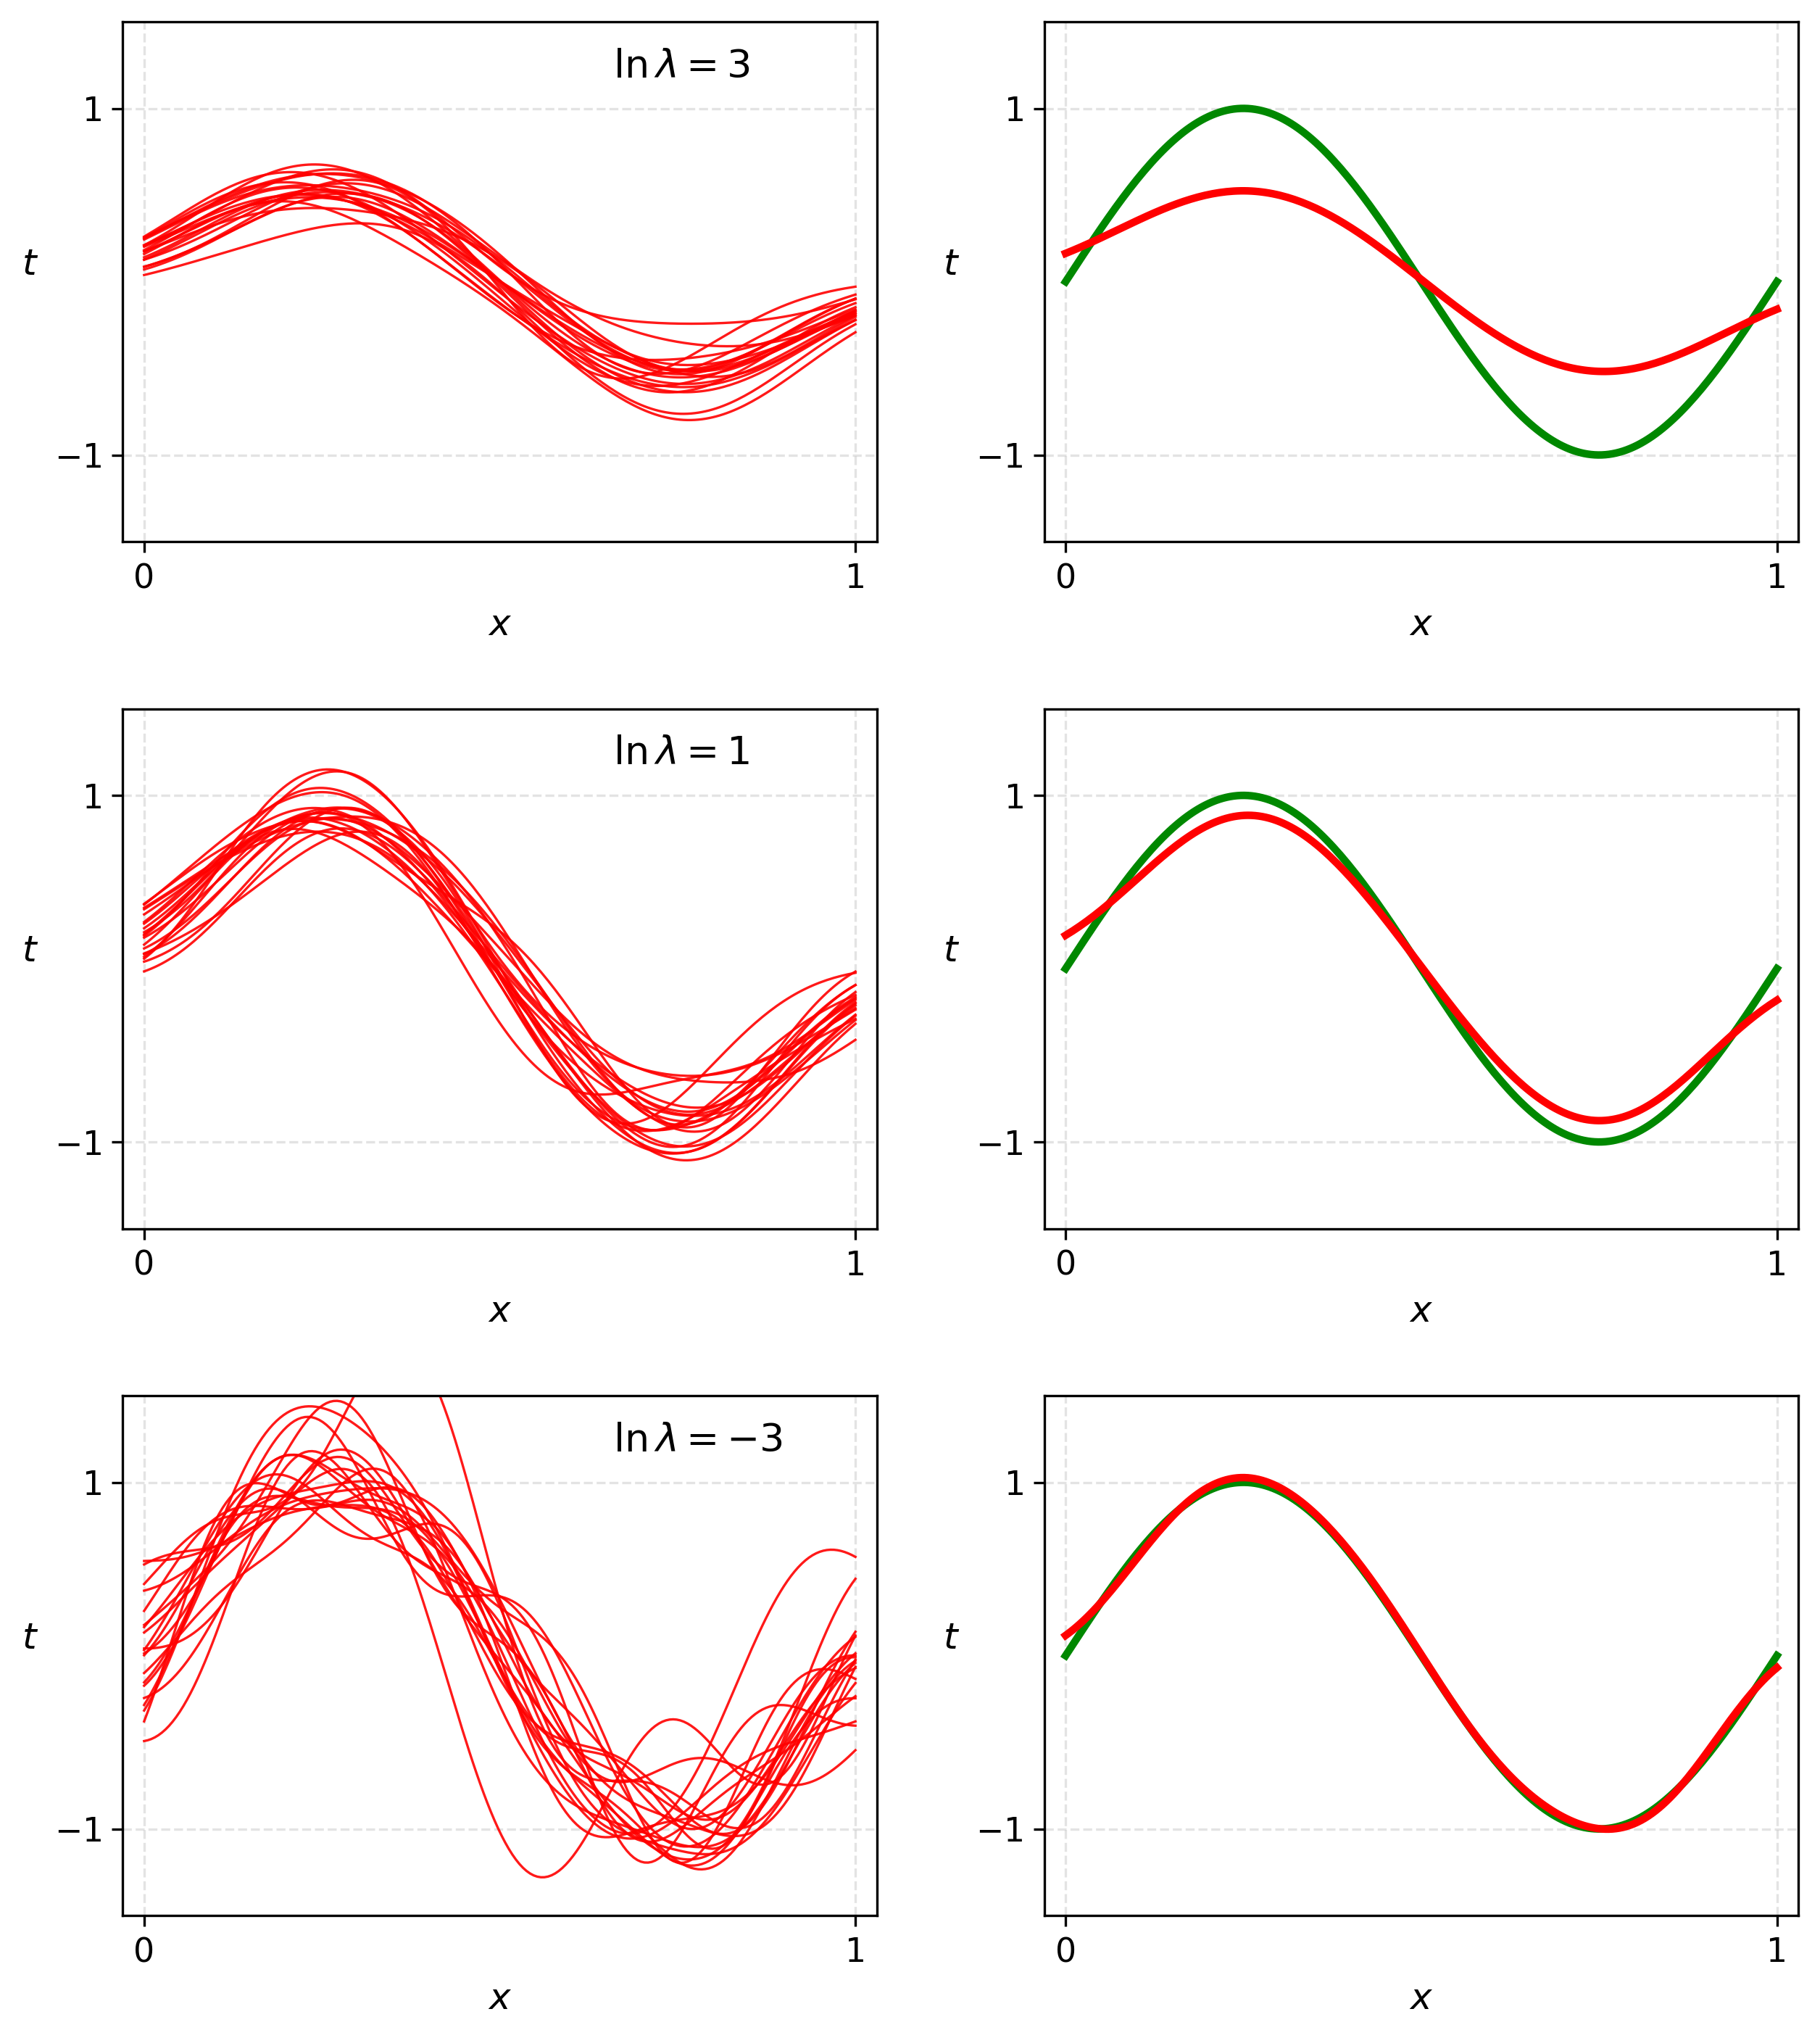

In [3]:
# Figure 4.7 の忠実な再現
fig4_7, axes4_7 = plot_figure_4_7_bias_variance_ensembles(
    save_paths=[
        'result/fig4_07_bias_variance_ensembles.png',
        '4/result/fig4_07_bias_variance_ensembles.png'
    ],
    show=True
)


---
## 4.3.4 定量的評価と Figure 4.8 の再現

### 離散標本による積分量の近似 (式 4.50 - 4.52)
アンサンブル平均予測 $\bar{f}(x)$、積分二乗バイアス $(\text{bias})^2$、積分バリアンス $\text{variance}$ は、評価点グリッド $\{x_n\}_{n=1}^{N_{\text{eval}}}$ 上の有限和として次のように数値計算されます：
$$
\bar{f}(x) = \frac{1}{L} \sum_{l=1}^L f^{(l)}(x) \tag{4.50}
$$
$$
(\text{bias})^2 = \frac{1}{N_{\text{eval}}} \sum_{n=1}^{N_{\text{eval}}} \{\bar{f}(x_n) - h(x_n)\}^2 \tag{4.51}
$$
$$
\text{variance} = \frac{1}{N_{\text{eval}}} \sum_{n=1}^{N_{\text{eval}}} \frac{1}{L} \sum_{l=1}^L \{f^{(l)}(x_n) - \bar{f}(x_n)\}^2 \tag{4.52}
$$

また、モデルの汎化性能を評価するため、独立にサンプリングした $1000$ 点のテストデータに対する平均二乗誤差（$\text{test error}$）も同時に計測します。


Figure 4.8 saved to: result/fig4_08_bias_variance_tradeoff.png
Figure 4.8 saved to: 4/result/fig4_08_bias_variance_tradeoff.png


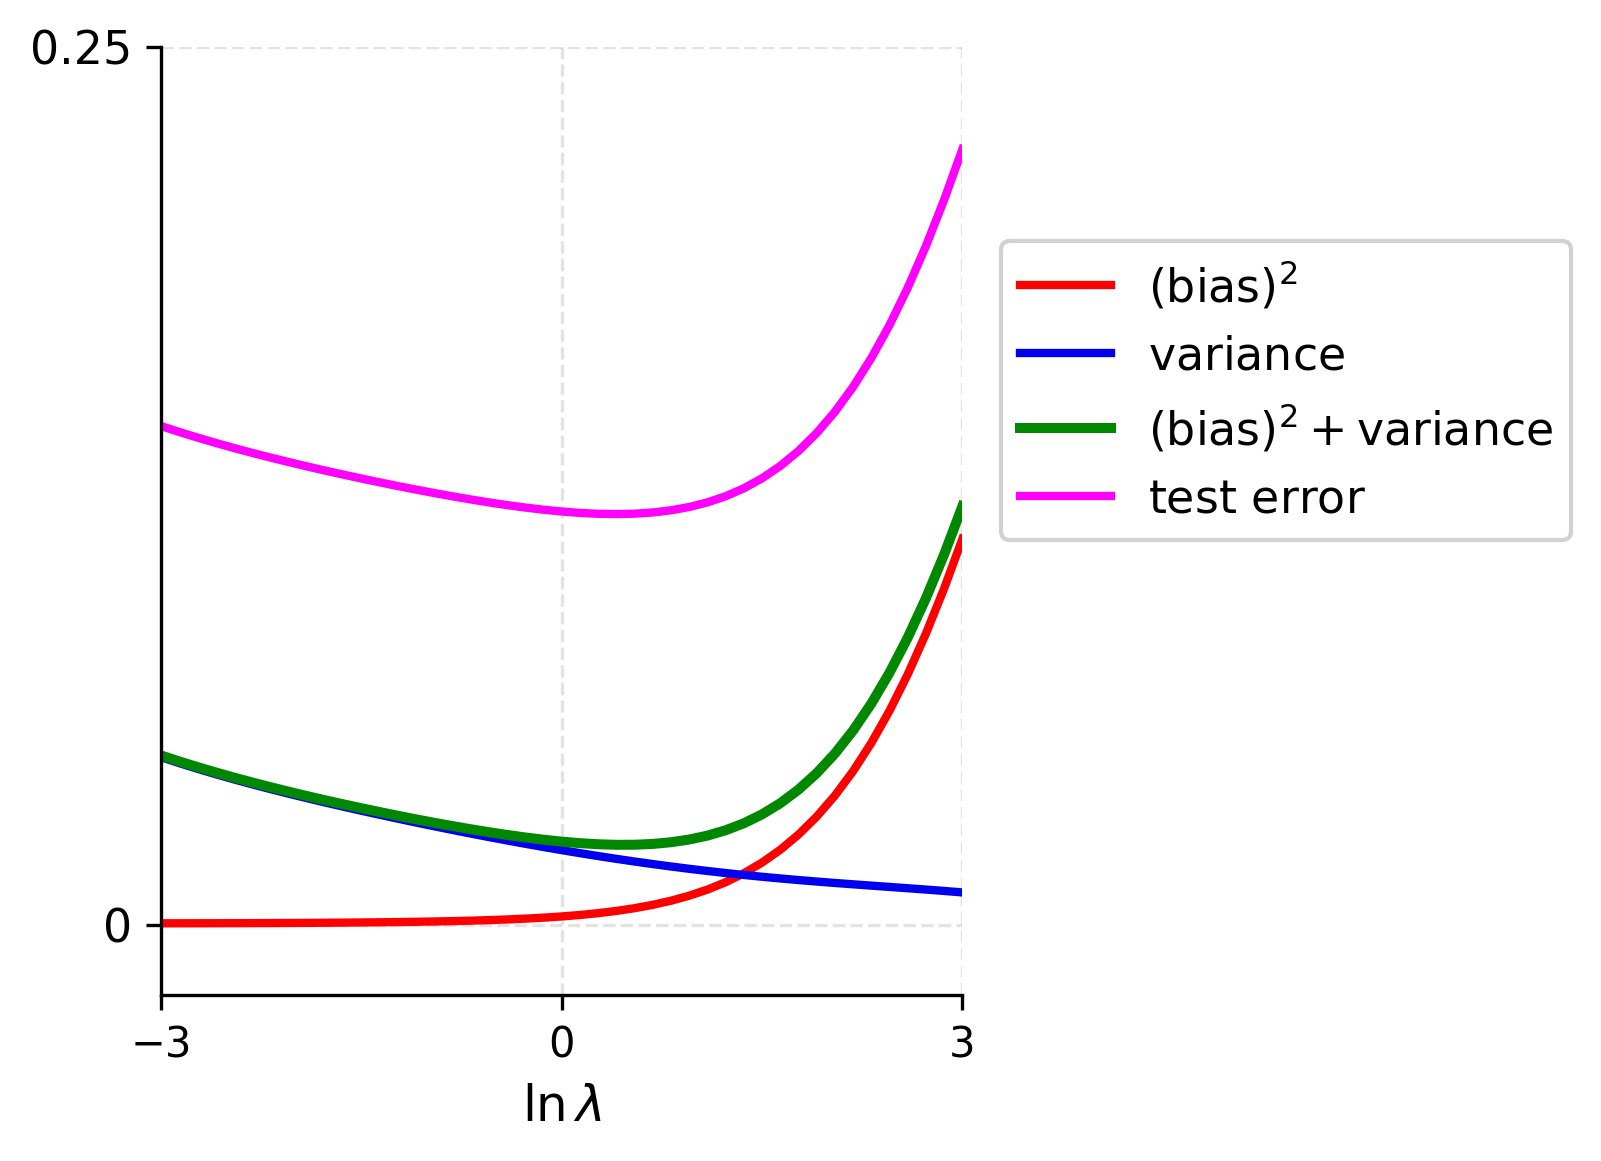

In [4]:
# Figure 4.8 の忠実な再現
fig4_8, ax4_8 = plot_figure_4_8_bias_variance_tradeoff(
    save_paths=[
        'result/fig4_08_bias_variance_tradeoff.png',
        '4/result/fig4_08_bias_variance_tradeoff.png'
    ],
    show=True
)


---
## 4.3.5 バイアス–バリアンス・トレードオフの重要洞察と現代的意義

### 1. トレードオフの極小点
Figure 4.8 から明らかなように：
- $\ln \lambda$ が小さい領域では、モデルは各データセットの固有ノイズに過剰適合するため、$\text{variance}$ が支配的になります。
- $\ln \lambda$ が大きい領域では、重みが $0$ に強く引き寄せられてモデルが硬直化するため、$(\text{bias})^2$ が支配的になります。
- 最も予測性能の高いモデルは、$(\text{bias})^2 + \text{variance}$ の和が最小となる $\ln \lambda \approx 0$ 付近に存在し、これはテスト誤差 $\text{test error}$ の最小点と正確に一致します。

---

### 2. アンサンブル平均（モデル平均化）の威力
Figure 4.7 の最下段（$\ln \lambda = -3$）において極めて示唆に富む現象が観察されます：
- 個々のモデル $f^{(l)}(x)$ は過学習により大きく暴れているにもかかわらず、それらの**単純平均 $\bar{f}(x)$ は真の関数 $h(x)$ を見事に復元**しています。
- 各モデルの分散（ノイズによるランダムな振れ）は正負互いに打ち消し合いますが、真のシグナルに対するバイアスは低いため、平均化によって劇的に誤差が低減するのです。
- この原理は、現代の**バギング (Bagging)**、**ランダムフォレスト (Random Forest)**、およびニューラルネットワークの**アンサンブル学習**の数学的基礎となっています。

---

### 3. ベイズ主義との対比
- **頻度論の限界**:
  バイアス–バリアンス分解は「同一分布からの多数の独立データセット $\mathcal{D}^{(l)}$ のアンサンブル」に対する平均に基づいています。しかし実世界では、手元には**たった1つのデータセット $\mathcal{D}$** しか存在しません。もし複数のデータセットが得られるならば、それらを平均するのではなく、**1つの大きなデータセットに結合して訓練する方が常に優れた性能を発揮**します（データサイズ $N$ が増大して過学習が直接軽減されるため）。
- **ベイズ主義のアプローチ**:
  ベイズ推論では、データセットのアンサンブルを仮想的に考えるのではなく、**与えられた単一のデータセット $\mathcal{D}$ に基づくパラメータの事後分布 $p(\mathbf{w}|\mathcal{D})$** を求め、パラメータ全体を重み付け積分（マージナライゼーション）して予測分布を求めます：
  $$
  p(t|\mathbf{x}, \mathcal{D}) = \int p(t|\mathbf{x}, \mathbf{w}) p(\mathbf{w}|\mathcal{D}) \, d\mathbf{w}
  $$
  これにより、パラメータの過学習そのものを自然に回避することができます。


In [5]:
# 自己採点アサーションセル (Self-scoring assertions)
sim = BiasVarianceSimulator(n_datasets=100, n_samples=25, noise_std=0.3, random_state=42)

# 1. ln lambda = 3 で高バイアス・低バリアンスであること
m_3 = sim.compute_metrics(lam=np.exp(3.0))
assert m_3['bias2'] > 0.08, f"Expected high bias, got {m_3['bias2']}"
assert m_3['variance'] < 0.02, f"Expected low variance, got {m_3['variance']}"
assert m_3['bias2'] > m_3['variance'], "Bias should dominate at ln lambda = 3"

# 2. ln lambda = -3 で低バイアス・高バリアンスであること
m_neg3 = sim.compute_metrics(lam=np.exp(-3.0))
assert m_neg3['bias2'] < 0.01, f"Expected low bias, got {m_neg3['bias2']}"
assert m_neg3['variance'] > 0.03, f"Expected high variance, got {m_neg3['variance']}"
assert m_neg3['variance'] > m_neg3['bias2'], "Variance should dominate at ln lambda = -3"

# 3. 最適点 (ln lambda = 0 付近) の和が両極端より小さいこと
m_0 = sim.compute_metrics(lam=np.exp(0.0))
assert m_0['bias2_plus_variance'] < m_3['bias2_plus_variance'], "Total error should be smaller than at ln lambda = 3"
assert m_0['bias2_plus_variance'] < m_neg3['bias2_plus_variance'], "Total error should be smaller than at ln lambda = -3"

# 4. テスト誤差が (bias)^2 + variance + noise_variance と整合すること
noise_variance = 0.3 ** 2 # 0.09
expected_test = m_0['bias2_plus_variance'] + noise_variance
assert np.isclose(m_0['test_error'], expected_test, rtol=0.2), f"Test error mismatch: {m_0['test_error']} vs {expected_test}"

# 5. 生成図版ファイルの存在確認
assert os.path.exists('result/fig4_07_bias_variance_ensembles.png'), "Figure 4.7 missing in result/"
assert os.path.exists('4/result/fig4_07_bias_variance_ensembles.png'), "Figure 4.7 missing in 4/result/"
assert os.path.exists('result/fig4_08_bias_variance_tradeoff.png'), "Figure 4.8 missing in result/"
assert os.path.exists('4/result/fig4_08_bias_variance_tradeoff.png'), "Figure 4.8 missing in 4/result/"

print("=" * 60)
print("ALL ASSERTIONS PASSED! Chapter 4 Section 4.3 Implementation is 100% verified.")
print("=" * 60)


ALL ASSERTIONS PASSED! Chapter 4 Section 4.3 Implementation is 100% verified.


---
## まとめと次節への展望

本ノートブックでは、Bishop & Bishop (2024) Chapter 4 の **Section 4.3 The Bias–Variance Trade-off** を網羅的に実装し、理論と数値シミュレーションの双方から探求しました。

### 達成事項の要約
1. **二乗損失の直交分解**: 固有ノイズとモデル予測誤差への分離（式 4.41 - 4.42）。
2. **バイアス–バリアンス分解の証明**: 頻度論的アンサンブルにおける期待値操作により、交差項が厳密に $0$ になることを数式と数値の双方で証明（式 4.44 - 4.45）。
3. **Figure 4.7 の完全再現**: 24個のガウス基底関数を用いた Ridge 回帰モデル群に対し、$\ln \lambda = 3, 1, -3$ における個別曲線とアンサンブル平均曲線の振る舞いを可視化。
4. **Figure 4.8 の完全再現**: 正則化係数 $\ln \lambda$ の変化に伴う $(\text{bias})^2$、$\text{variance}$、それらの和、および $\text{test error}$ の定量的推移の再現。
5. **モデル平均化の洞察**: 表現力の高いモデル群の平均化が優れた予測を生み出すメカニズムの解明と、ベイズ推論・アンサンブル学習への接続。

次節では、第4章の締めくくりとして、これまでに学んだ線形回帰、決定理論、バイアス–バリアンス・トレードオフを総括する**第4章 演習問題 (Exercises 4.1 〜 4.12)** に挑戦します！
